In [10]:
import pandas as pd

train = pd.read_csv("../data/raw/train.csv")
test = pd.read_csv("../data/raw/test.csv")
sample_out = pd.read_csv("../data/raw/sample_test_out.csv")

print("train:", train.shape)
print("test:", test.shape)
print(train.columns.tolist())
train.head()

train: (75000, 4)
test: (75000, 3)
['sample_id', 'catalog_content', 'image_link', 'price']


,sample_id,catalog_content,image_link,price
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97
3,55858,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.34
4,292686,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",https://m.media-amazon.com/images/I/41sA037+Qv...,66.49


In [11]:
sample_out.head()

,sample_id,price
0,217392,62.080008
1,209156,17.189763
2,262333,96.501410
3,295979,5.652474
4,50604,23.794780


In [12]:
print("Missing (train):\n", train.isna().sum())
print("Missing (test):\n", test.isna().sum())
print("Duplicate sample_id train/test:",train.sample_id.duplicated().sum(), test.sample_id.duplicated().sum())
print("ID overlap train/test:", len(set(train.sample_id) & set(test.sample_id)))
print("Empty catalog_content (train):", (train.catalog_content.fillna("").str.strip() == "").sum())

Missing (train):
 sample_id          0
catalog_content    0
image_link         0
price              0
dtype: int64
Missing (test):
 sample_id          0
catalog_content    0
image_link         0
dtype: int64
Duplicate sample_id train/test: 0 0
ID overlap train/test: 0
Empty catalog_content (train): 0


count    75000.000000
mean        23.647654
std         33.376932
min          0.130000
1%           1.320000
5%           2.440000
25%          6.795000
50%         14.000000
75%         28.625000
95%         75.711000
99%        145.250300
99.9%      322.121740
max       2796.000000
Name: price, dtype: float64
Zero/negative prices: 0
Skew raw: 13.601388975432753 | Skew log1p: 0.20392350587391725


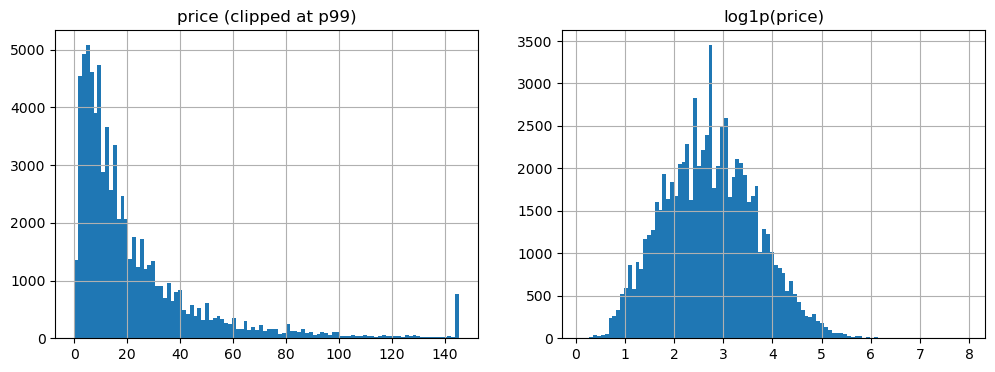

In [13]:
import numpy as np
import matplotlib.pyplot as plt

p = train["price"]
print(p.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99, .999]))
print("Zero/negative prices:", (p <= 0).sum())
print("Skew raw:", p.skew(), "| Skew log1p:", np.log1p(p).skew())

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
p.clip(upper=p.quantile(0.99)).hist(bins=100, ax=ax[0]); 
ax[0].set_title("price (clipped at p99)")
np.log1p(p).hist(bins=100, ax=ax[1]); 
ax[1].set_title("log1p(price)")
plt.show()

In [14]:
dup_text_train = train.catalog_content.duplicated(keep=False)
print("Rows in train with duplicated catalog_content:", dup_text_train.sum())
print("Duplicated image_link (train):", train.image_link.duplicated().sum())

overlap = test.catalog_content.isin(set(train.catalog_content))
print("Test rows whose catalog_content appears exactly in train:", overlap.sum())

g = train[dup_text_train].groupby("catalog_content")["price"].agg(["count", "min", "max"])
g["ratio"] = g["max"] / g["min"]
print(g["ratio"].describe())

Rows in train with duplicated catalog_content: 193
Duplicated image_link (train): 2712
Test rows whose catalog_content appears exactly in train: 234
count    93.000000
mean      1.779968
std       1.927135
min       1.000000
25%       1.000000
50%       1.131280
75%       1.636198
max      16.102222
Name: ratio, dtype: float64


In [15]:
import sys
sys.path.append("..")
from src.metrics import smape

print("Sanity check:", round(smape([100], [120]), 2))  # should be 18.18

y = train.price.values
cands = {
    "mean": y.mean(),
    "median": np.median(y),
    "geo_mean": np.exp(np.log(y[y > 0]).mean()),
}
grid = np.linspace(np.percentile(y, 5), np.percentile(y, 95), 400)
best_c = grid[np.argmin([smape(y, np.full_like(y, c)) for c in grid])]
cands["best_constant"] = best_c
for k, v in cands.items():
    print(f"{k:14s} c={v:8.3f}  SMAPE={smape(y, np.full_like(y, v)):.2f}%")

Sanity check: 18.18
mean           c=  23.648  SMAPE=79.06%
median         c=  14.000  SMAPE=72.70%
geo_mean       c=  13.884  SMAPE=72.72%
best_constant  c=  14.376  SMAPE=72.69%


In [9]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.metrics import smape
print("Sanity check:", round(smape([100], [120]), 2))   # should be 18.18

Sanity check: 18.18
